In [85]:
###### imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import matplotlib.image as mpimg
from pathlib import Path
import re
from scipy.ndimage import binary_fill_holes, binary_closing, label

In [86]:
###### Global Variables

UNITS = {
    'rsrp' : 'dBm',
    'rsrq' : 'dB',
    'cinr' : 'dB',
    'rssi' : 'dBm',
    'tests' : 'count',
    'pci' : '',
    'freq' : 'MHz',
    'band' : '',
    'network' : '',
    'source' : '',
}

#TODO: include ACTUAL signal ranges here eventuallys
SIGNAL_RANGES = {
    'rsrp' : (-140, -44),
    'rsrq' : (-43, 20),
    'cinr' : (-23, 40),
    'rssi' : (-100, 0),
}

# TODO: make clear
# common schema every reduced file maps into
METRICS = ['rsrp', 'rsrq', 'cinr', 'rssi']
NUM_COLS = ['rsrp', 'rsrq', 'cinr', 'rssi']
ID_COLS = {'pci', 'freq', 'band', 'network'}
OTHER = {'source', 'n_samples'}

In [87]:
#### Input

DATA_DIR = Path('./Data')
CSV_DIR = DATA_DIR / 'WHOLE LOT OF csv'

# floor plan raster + its MapInfo georeference (pixel <-> lat/lon control points)
FLOOR_MAP_PNG = './Residual_Map_7th_Floor.png'
FLOOR_MAP_TAB = './Residual_Map_7th_Floor.tab'

# file-type glob patterns (indoor gflex export drops one csv per band / channel)
PAT_LTE_BLIND = '*LTE*DL_Blind Scan.CSV'
PAT_LTE_TOPN = '*Enhanced Top N Signal*MHz.CSV'
PAT_NR_TOPN = '*nr Top N Signal*kHz.CSV'
PAT_BEST_SERVING = '*_BestServing.CSV'

In [95]:
####### Functions

def time_to_millisec(time):
    parts = time.split(":")
    h,m,s,millis = int(parts[0]),int(parts[1]),int(parts[2]),int(float(parts[3]))
    return h * 3600000 + m * 60000 + s * 1000 + millis

# read csv file using pandas
def read_csv(path):
    df = pd.read_csv(path)
    return df

# read every csv matching a pattern and concat, tagging each row with its source file
def read_concat_csvs(pattern, exclude='_BestServing'):
    frames = []
    for p in sorted(CSV_DIR.glob(pattern)): #iterate through csv
        if exclude and exclude in p.name:
            continue
        df = read_csv(p) #read csv into dataframe
        df['source'] = p.stem
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

#TODO: determine neccesary metrics
# reduce & rename lte blind scan data to the common schema
def reduce_lte_blind(df):
    df = df.rename(columns={
        'Latitude' : 'latitude',
        'Longitude' : 'longitude',
        'Cell Id' : 'pci',
        'Channel Number' : 'freq',
        'Channel RSSI' : 'rssi',
        'Ref Signal - Received Power' : 'rsrp',
        'Ref Signal - Received Quality' : 'rsrq',
        'Ref Signal - CINR' : 'cinr',
    })
    df['time(ms)'] = df['Time'].apply(time_to_millisec)  #Shift scanner time to milliseconds
    df['network'] = 'lte'  
    df = df[['time(ms)', 'latitude', 'longitude', 'pci', 'freq', 'rsrp', 'rsrq', 'cinr', 'rssi', 'network', 'source']]
    return df

# reduce & rename nr top n data to the common schema (SSS-based measurements)
def reduce_nr_topn(df):
    df = df.rename(columns={
        'Latitude' : 'latitude',
        'Longitude' : 'longitude',
        'Cell ID' : 'pci',
        'Channel Frequency' : 'freq',
        'SSB RSSI' : 'rssi',
        'SSS_RP' : 'rsrp',
        'SSS_RQ' : 'rsrq',
        'SS_CINR' : 'cinr',
        'Band' : 'band',
    })
    df['time(ms)'] = df['System Time'].apply(time_to_millisec) #Shift scanner time to milliseconds
    df['network'] = 'nr' 
    df = df[['time(ms)', 'latitude', 'longitude', 'pci', 'freq', 'rsrp', 'rsrq', 'cinr', 'rssi', 'band', 'network', 'source']]
    return df

######### floor plan georeference functions

# parse GCP lines out of the mapinfo .tab file: (lon,lat) (px,py)
def read_tab_gcps(tab_path):
    pattern = re.compile(r'\((-?[\d.]+),(-?[\d.]+)\)\s*\((\d+),(\d+)\)') #regular expression extracts coordinates and dimensions formatted in pairs
    gcps = []
    for line in Path(tab_path).read_text().splitlines():
        m = pattern.search(line)
        if m:
            lon, lat, px, py = map(float, m.groups())
            gcps.append((lon, lat, px, py))
    return pd.DataFrame(gcps, columns=['longitude', 'latitude', 'px', 'py'])

# least-squares affine fit: (lon, lat) -> (px, py)
def fit_affine(gcps):
    A = np.column_stack([gcps['longitude'], gcps['latitude'], np.ones(len(gcps))])
    coef_x, *_ = np.linalg.lstsq(A, gcps['px'], rcond=None)
    coef_y, *_ = np.linalg.lstsq(A, gcps['py'], rcond=None)

    # report fit residuals (px) so we know how trustworthy the transform is
    res_x = A @ coef_x - gcps['px']
    res_y = A @ coef_y - gcps['py']
    rmse = np.sqrt(np.mean(res_x**2 + res_y**2))
    print(f'affine fit rmse: {rmse:.1f} px over {len(gcps)} GCPs')

    return coef_x, coef_y

# add pixel coords to a dataframe using the affine transform(coef_x, coef_y)
def add_pixel_coords(df, coef_x, coef_y):
    df = df.copy()
    A = np.column_stack([df['longitude'], df['latitude'], np.ones(len(df))])
    df['px'] = A @ coef_x
    df['py'] = A @ coef_y
    return df

######### plotting

# scatter measurement points on the floor plan colored by a signal metric
def plot_floor_signal(df, metric, title=None, figsize=(14, 8), cmap='viridis', vmin=None, vmax=None, point_size=60, show_boundary=True, boundary_color='red', boundary_width=2, boundary_ink_thresh=0.95, boundary_close_px=15, boundary_warp_gcp=True, gcp_points=None, lock_to_map=True, boundary_mode='auto', boundary_regular_color='orange', boundary_warp_color='cyan', save_path=None, show=True, add_wrap_png=False, wrap_save_path=None, wrap_boundary_mode='both', wrap_show=False):
    unit = UNITS.get(metric, '')
    vrange = SIGNAL_RANGES.get(metric, (None, None))
    col_data = df[metric].dropna()
    vmin = vmin if vmin is not None else col_data.quantile(0.02)
    vmax = vmax if vmax is not None else col_data.quantile(0.98)

    img = mpimg.imread(FLOOR_MAP_PNG)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)

    if show_boundary:
        try:
            _, mask = floor_footprint(FLOOR_MAP_PNG, ink_thresh=boundary_ink_thresh, close_px=boundary_close_px)
        except Exception:
            # Fallback if floor_footprint or morphology imports are unavailable.
            gray = img[:, :, :3].mean(axis=2)
            mask = gray < boundary_ink_thresh

        def draw_regular(color):
            ax.contour(mask.astype(float), levels=[0.5], colors=color, linewidths=boundary_width)

        def draw_warped(color):
            gcp_df = gcp_points if gcp_points is not None else globals().get('gcps', None)
            cx = globals().get('coef_x', None)
            cy = globals().get('coef_y', None)
            can_warp = gcp_df is not None and cx is not None and cy is not None and len(gcp_df) >= 3
            if not can_warp:
                return False

            A_inv = np.column_stack([gcp_df['px'], gcp_df['py'], np.ones(len(gcp_df))])
            coef_lon, *_ = np.linalg.lstsq(A_inv, gcp_df['longitude'], rcond=None)
            coef_lat, *_ = np.linalg.lstsq(A_inv, gcp_df['latitude'], rcond=None)

            cs = ax.contour(mask.astype(float), levels=[0.5], colors='none', linewidths=0)
            segs = cs.allsegs[0] if hasattr(cs, 'allsegs') and len(cs.allsegs) else []
            try:
                cs.remove()
            except Exception:
                pass

            for seg in segs:
                if len(seg) < 2:
                    continue
                B = np.column_stack([seg[:, 0], seg[:, 1], np.ones(len(seg))])
                lon = B @ coef_lon
                lat = B @ coef_lat
                A = np.column_stack([lon, lat, np.ones(len(seg))])
                xw = A @ cx
                yw = A @ cy
                ax.plot(xw, yw, color=color, linewidth=boundary_width)
            return True

        mode = boundary_mode if boundary_mode in {'regular', 'warped', 'both'} else ('warped' if boundary_warp_gcp else 'regular')
        if mode == 'regular':
            draw_regular(boundary_color)
        elif mode == 'warped':
            if not draw_warped(boundary_color):
                draw_regular(boundary_color)
        else:
            draw_regular(boundary_regular_color)
            draw_warped(boundary_warp_color)

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    ax.scatter(df['px'], df['py'], c=df[metric], cmap=cmap, norm=norm,
               s=point_size, edgecolors='black', linewidths=0.3, alpha=0.9)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.7, pad=0.01)
    cbar.set_label(f'{metric.upper()} ({unit})', fontsize=11)
    ticks = np.linspace(vmin, vmax, 9)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f'{t:.0f} {unit}' for t in ticks])
    cbar.ax.tick_params(labelsize=8)

    if lock_to_map:
        h, w = img.shape[:2]
        ax.set_xlim(0, w)
        ax.set_ylim(h, 0)

    ax.set_axis_off()
    ax.set_title(title or f'{metric.upper()} ({unit}) — 7th floor walk test', fontsize=13, pad=10)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=220, bbox_inches='tight')

    if show:
        plt.show()
    else:
        plt.close(fig)

    if add_wrap_png:
        wrap_out = wrap_save_path
        if wrap_out is None and save_path:
            sp = Path(save_path)
            wrap_out = sp.with_name(f'{sp.stem}_wrapped{sp.suffix}')

        plot_floor_signal(
            df, metric,
            title=(title + ' — wrapped boundary') if title else None,
            figsize=figsize, cmap=cmap, vmin=vmin, vmax=vmax, point_size=point_size,
            show_boundary=show_boundary,
            boundary_color=boundary_color, boundary_width=boundary_width,
            boundary_ink_thresh=boundary_ink_thresh, boundary_close_px=boundary_close_px,
            boundary_warp_gcp=boundary_warp_gcp, gcp_points=gcp_points,
            lock_to_map=lock_to_map,
            boundary_mode=wrap_boundary_mode,
            boundary_regular_color=boundary_regular_color,
            boundary_warp_color=boundary_warp_color,
            save_path=wrap_out,
            show=wrap_show,
            add_wrap_png=False
        )

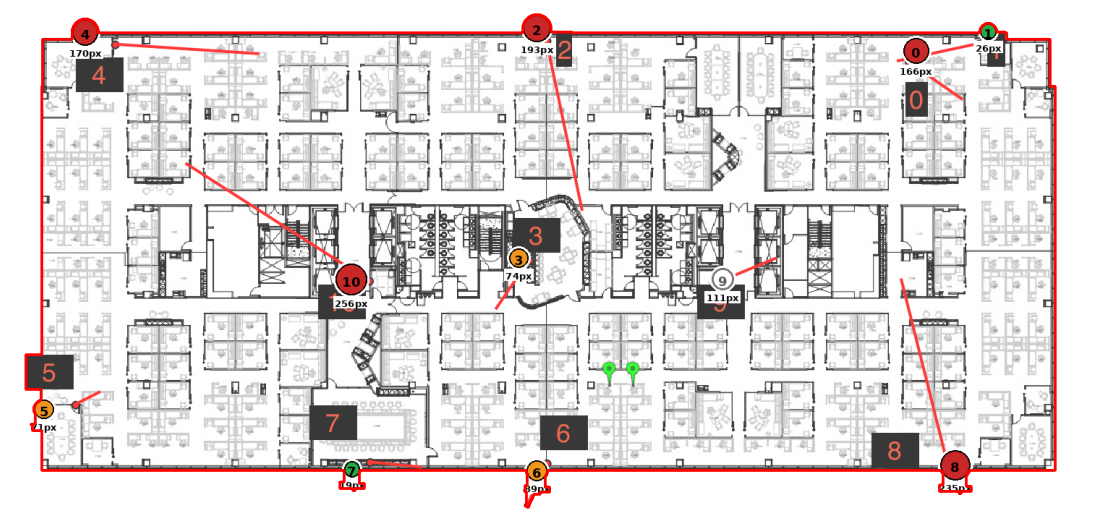

In [89]:

# boundary_test
#  building footprint mask + outline for a floor plan with no alpha channel
def floor_footprint(image_path=FLOOR_MAP_PNG, ink_thresh=0.95, close_px=15):
    img = mpimg.imread(image_path)
    gray = img[:, :, :3].mean(axis=2)
    ink = gray < ink_thresh                    # anything that isn't white paper
    filled = binary_fill_holes(binary_closing(ink, structure=np.ones((close_px, close_px))))
    lab, n = label(filled)                     # keep only the largest blob (the building)
    if n > 1:
        sizes = np.bincount(lab.ravel()); sizes[0] = 0
        filled = lab == sizes.argmax()
    return img, filled


def plot_png_with_boundary(image_path=FLOOR_MAP_PNG, boundary_color='red', boundary_width=2):
    img, mask = floor_footprint(image_path)
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(img)
    ax.contour(mask.astype(float), levels=[0.5], colors=boundary_color, linewidths=boundary_width)
    ax.axis('off')
    plt.show()

plot_png_with_boundary()


In [90]:
# read csv file using pandas
df_lte = reduce_lte_blind(read_concat_csvs(PAT_LTE_BLIND))
df_nr = reduce_nr_topn(read_concat_csvs(PAT_NR_TOPN))

#TODO: determine necessary columns, may need to rename
df = pd.concat([df_lte, df_nr], ignore_index=True)
df = df.sort_values(by='time(ms)', ignore_index=True)

print(f'lte rows: {len(df_lte)}, nr rows: {len(df_nr)}')
print(df.head())
df.to_csv('./concat_indoor_walk_test.csv', index=False)

lte rows: 2838, nr rows: 1054
   time(ms)   latitude  longitude    pci     freq    rsrp   rsrq  cinr  rssi  \
0  57346664  38.903706 -77.007056  538.0  1935.85 -103.24 -13.96 -0.06 -75.9   
1  57346671  38.903696 -77.006977  538.0  1935.85 -104.74 -14.72 -1.65 -76.8   
2  57346671  38.903701 -77.007017  538.0  1935.85 -104.04 -14.35 -0.79 -76.1   
3  57346672  38.903691 -77.006938  538.0  1935.85 -103.70 -14.24 -0.40 -75.8   
4  57349564  38.903706 -77.007056  538.0  1935.85 -105.85 -15.14 -2.00 -76.6   

  network                                             source  band  
0      nr  Gflex Device 032409007_NR_FR1 FDD n2 DL_nr Top...   2.0  
1      nr  Gflex Device 032409007_NR_FR1 FDD n2 DL_nr Top...   2.0  
2      nr  Gflex Device 032409007_NR_FR1 FDD n2 DL_nr Top...   2.0  
3      nr  Gflex Device 032409007_NR_FR1 FDD n2 DL_nr Top...   2.0  
4      nr  Gflex Device 032409007_NR_FR1 FDD n25 DL_nr To...  25.0  


In [91]:
# georeference: lat/lon -> floor plan pixels
gcps = read_tab_gcps(FLOOR_MAP_TAB)
coef_x, coef_y = fit_affine(gcps)

df = add_pixel_coords(df, coef_x, coef_y)
print(df[['latitude', 'longitude', 'px', 'py']].describe())

affine fit rmse: 170.9 px over 11 GCPs
          latitude    longitude           px           py
count  3892.000000  3892.000000  3892.000000  3892.000000
mean     38.903465   -77.006299  2893.483880   528.522385
std       0.000115     0.000532  1057.411505   208.038148
min      38.903262   -77.007502   558.890795   108.948651
25%      38.903376   -77.006652  2178.445911   412.989057
50%      38.903466   -77.006193  3119.145774   509.473764
75%      38.903539   -77.005914  3640.424495   687.688585
max      38.903706   -77.005299  4818.764670   905.681112


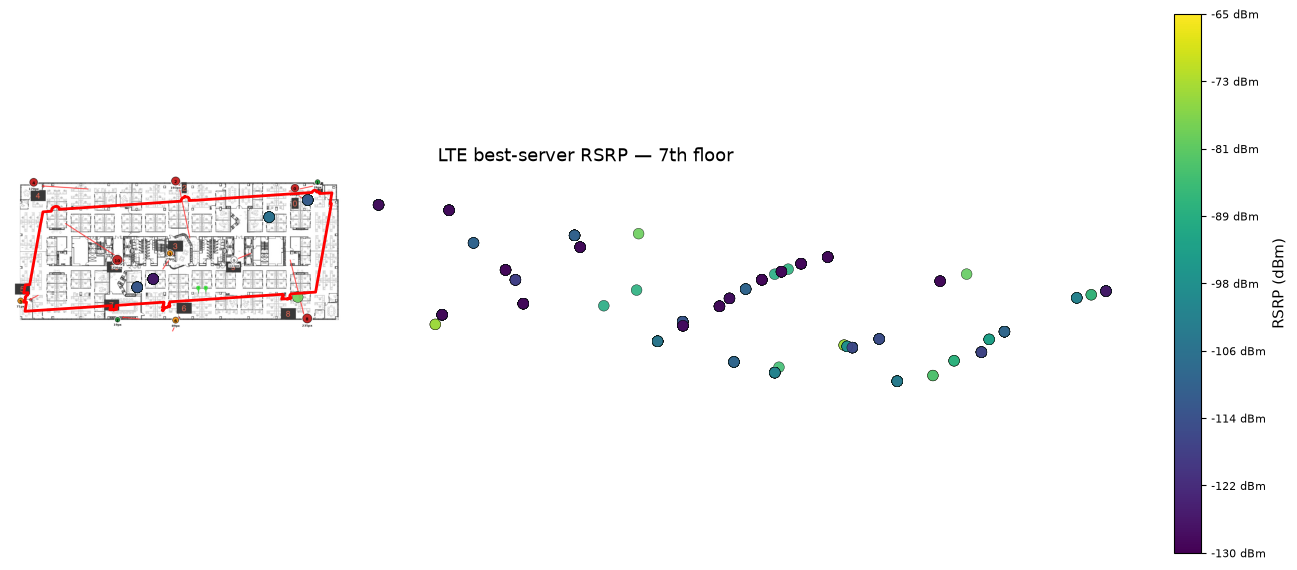

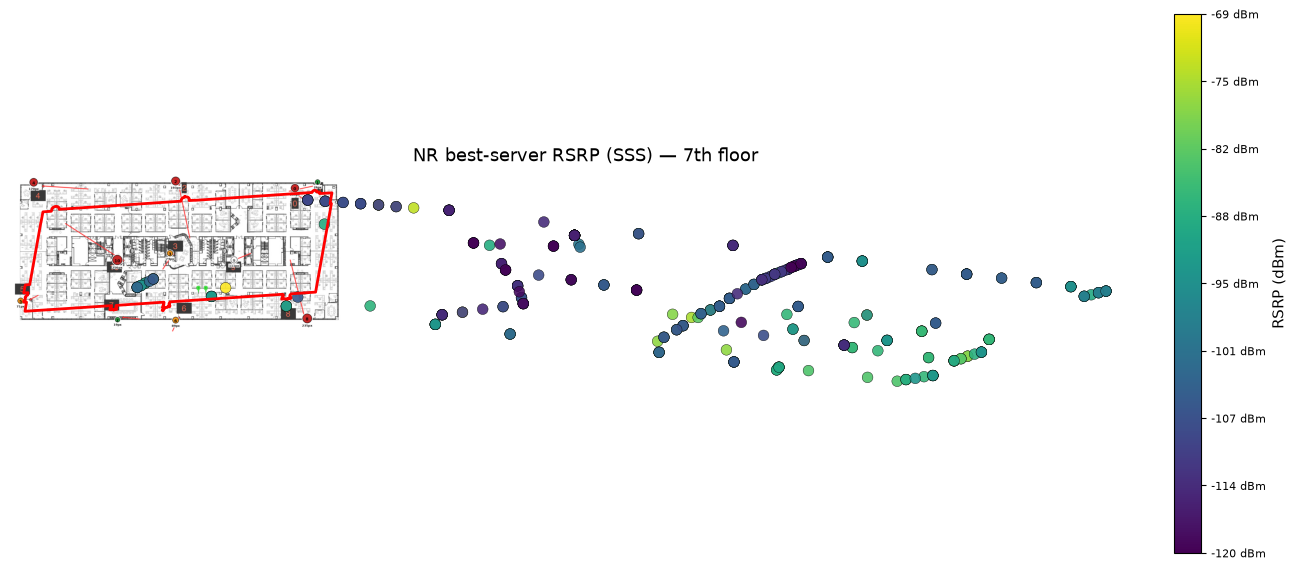

In [96]:
# plot strongest cell per measurement point (best rsrp at each time/location)
df_best = df.sort_values('rsrp', ascending=False).drop_duplicates(subset=['time(ms)', 'network'])

plot_floor_signal(
    df_best[df_best['network'] == 'lte'],
    'rsrp',
    title='LTE best-server RSRP — 7th floor',
    boundary_mode='warped',
    boundary_color='red',
    lock_to_map=False
 )
plot_floor_signal(
    df_best[df_best['network'] == 'nr'],
    'rsrp',
    title='NR best-server RSRP (SSS) — 7th floor',
    boundary_mode='warped',
    boundary_color='red',
    lock_to_map=False
 )

Bounded transform (tx, ty, theta_deg, scale):
[0. 0. 0. 1.]
Optimization success: False | objective: 132.816
     group    n  inside_pct  in_bounds_pct  mean_dist_px
all_before 1838   11.262242      11.371055     56.589061
 all_after 1838   11.262242      11.371055     56.589061
lte_before 1411   11.977321      11.977321     56.483673
 lte_after 1411   11.977321      11.977321     56.483673
 nr_before  427    8.899297       9.367681     56.937313
  nr_after  427    8.899297       9.367681     56.937313


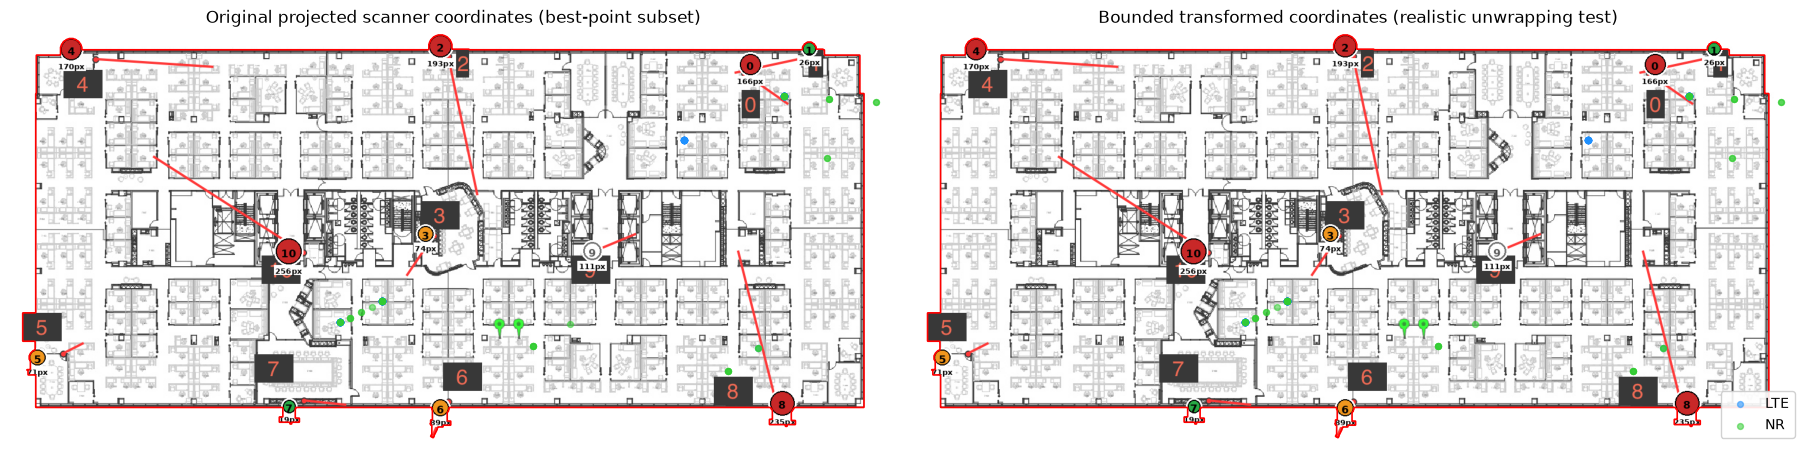

Saved: plots/alignment_test_bounded_original_vs_transformed.png


In [93]:
# alignment test (bounded): estimate a realistic transform from scanner px/py to floor-plan footprint
from scipy.ndimage import distance_transform_edt
from scipy.optimize import minimize

try:
    img_fp, mask_fp = floor_footprint(FLOOR_MAP_PNG, ink_thresh=0.95, close_px=15)
except Exception:
    img_fp = mpimg.imread(FLOOR_MAP_PNG)
    gray = img_fp[:, :, :3].mean(axis=2)
    mask_fp = gray < 0.95

h, w = mask_fp.shape
dist_out = distance_transform_edt(~mask_fp)

# use strongest points to reduce duplicated noisy samples
df_test = df.sort_values('rsrp', ascending=False).drop_duplicates(subset=['time(ms)', 'network']).copy()
xy0 = df_test[['px', 'py']].to_numpy()
orig_center = xy0.mean(axis=0)
orig_spread = np.sqrt(((xy0 - orig_center) ** 2).sum(axis=1).mean())

def apply_similarity(xy, params):
    tx, ty, theta, scale = params
    c = orig_center
    centered = xy - c
    ct, st = np.cos(theta), np.sin(theta)
    R = np.array([[ct, -st], [st, ct]])
    return scale * (centered @ R.T) + c + np.array([tx, ty])

def sample_dist_and_inside(xy):
    x = xy[:, 0]
    y = xy[:, 1]
    in_bounds = (x >= 0) & (x < w) & (y >= 0) & (y < h)
    xi = np.clip(np.rint(x).astype(int), 0, w - 1)
    yi = np.clip(np.rint(y).astype(int), 0, h - 1)
    d = dist_out[yi, xi]
    inside = np.zeros(len(xy), dtype=bool)
    inside[in_bounds] = mask_fp[yi[in_bounds], xi[in_bounds]]
    return d, inside, in_bounds

def alignment_cost(params, xy):
    warped = apply_similarity(xy, params)
    d, inside, in_bounds = sample_dist_and_inside(warped)

    # keep transform physically plausible
    scale = params[3]
    spread = np.sqrt(((warped - warped.mean(axis=0)) ** 2).sum(axis=1).mean())
    spread_ratio = spread / (orig_spread + 1e-9)

    outside_pen = (~inside) * 6.0 + (~in_bounds) * 80.0
    scale_pen = 80.0 * abs(scale - 1.0)
    spread_pen = 60.0 * abs(spread_ratio - 1.0)
    return float(np.mean(d + outside_pen) + scale_pen + spread_pen)

def metrics(frame):
    pts = frame[['px', 'py']].to_numpy()
    d, inside, in_bounds = sample_dist_and_inside(pts)
    return {
        'n': len(pts),
        'inside_pct': 100.0 * inside.mean(),
        'in_bounds_pct': 100.0 * in_bounds.mean(),
        'mean_dist_px': float(d.mean())
    }

# bounded optimization: translation + small rotation + modest scale
x0 = np.array([0.0, 0.0, 0.0, 1.0])
bounds = [
    (-0.75 * w, 0.75 * w),
    (-0.75 * h, 0.75 * h),
    (-np.pi / 6, np.pi / 6),
    (0.8, 1.2),
]
res = minimize(alignment_cost, x0, args=(xy0,), method='L-BFGS-B', bounds=bounds, options={'maxiter': 600})

df_test_aligned = df_test.copy()
df_test_aligned[['px', 'py']] = apply_similarity(df_test[['px', 'py']].to_numpy(), res.x)

m_before_all = metrics(df_test)
m_after_all = metrics(df_test_aligned)
m_before_lte = metrics(df_test[df_test['network'] == 'lte'])
m_after_lte = metrics(df_test_aligned[df_test_aligned['network'] == 'lte'])
m_before_nr = metrics(df_test[df_test['network'] == 'nr'])
m_after_nr = metrics(df_test_aligned[df_test_aligned['network'] == 'nr'])

print('Bounded transform (tx, ty, theta_deg, scale):')
print(np.round([res.x[0], res.x[1], np.degrees(res.x[2]), res.x[3]], 4))
print('Optimization success:', res.success, '| objective:', round(float(res.fun), 3))

summary = pd.DataFrame([
    {'group': 'all_before', **m_before_all},
    {'group': 'all_after', **m_after_all},
    {'group': 'lte_before', **m_before_lte},
    {'group': 'lte_after', **m_after_lte},
    {'group': 'nr_before', **m_before_nr},
    {'group': 'nr_after', **m_after_nr},
])
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
for ax, frame, ttl in [
    (axes[0], df_test, 'Original projected scanner coordinates (best-point subset)'),
    (axes[1], df_test_aligned, 'Bounded transformed coordinates (realistic unwrapping test)')
]:
    ax.imshow(img_fp)
    ax.contour(mask_fp.astype(float), levels=[0.5], colors='red', linewidths=1.2)
    lte = frame[frame['network'] == 'lte']
    nr = frame[frame['network'] == 'nr']
    ax.scatter(lte['px'], lte['py'], s=18, c='dodgerblue', alpha=0.55, label='LTE')
    ax.scatter(nr['px'], nr['py'], s=18, c='limegreen', alpha=0.55, label='NR')
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.set_axis_off()
    ax.set_title(ttl)

axes[1].legend(loc='lower right', framealpha=0.9)
Path('./plots').mkdir(exist_ok=True)
fig.savefig('./plots/alignment_test_bounded_original_vs_transformed.png', dpi=220, bbox_inches='tight')
plt.show()
print('Saved: plots/alignment_test_bounded_original_vs_transformed.png')

Regularized non-rigid warp search result:
 fit points kept: 209 / 1838 (trimmed 1629 extreme off-boundary points for fitting)
 best smooth=500.0, alpha=0.25
 validation fit err=0.01 px, mean displacement=0.01 px, shape ratio=1.000
     group  inside_pct  in_bounds_pct  mean_dist_px
all_before   11.262242      11.371055     56.589061
 all_after   11.262242      11.371055     56.748324
lte_before   11.977321      11.977321     56.483673
 lte_after   11.977321      11.977321     56.665441
 nr_before    8.899297       9.367681     56.937313
  nr_after    8.899297       9.367681     57.022204


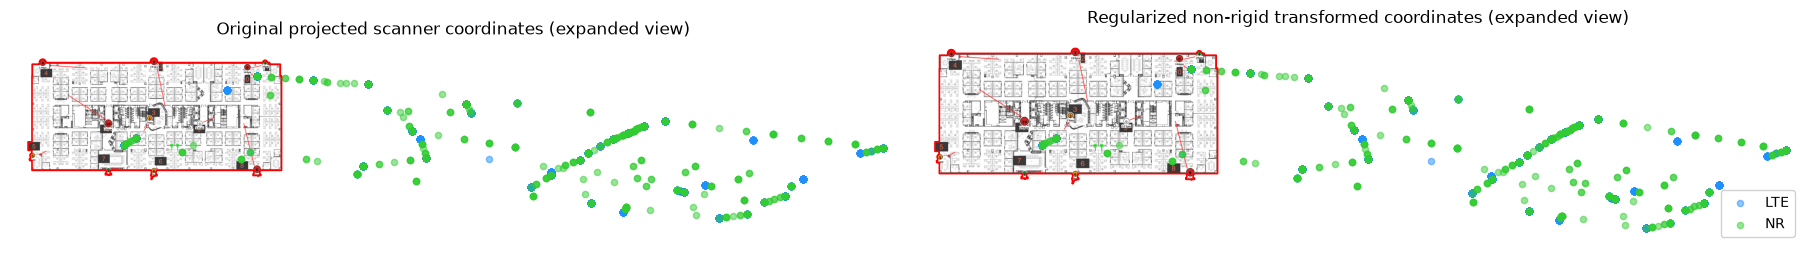

Saved: plots/alignment_test_regularized_nonrigid_expanded.png


In [94]:
# non-rigid test (regularized): thin-plate-style warp with validation + outlier trimming
from scipy.interpolate import Rbf
from scipy.ndimage import distance_transform_edt

# ensure footprint + distance fields are available
try:
    _ = mask_fp
    _ = img_fp
except NameError:
    try:
        img_fp, mask_fp = floor_footprint(FLOOR_MAP_PNG, ink_thresh=0.95, close_px=15)
    except Exception:
        img_fp = mpimg.imread(FLOOR_MAP_PNG)
        gray = img_fp[:, :, :3].mean(axis=2)
        mask_fp = gray < 0.95

h, w = mask_fp.shape
dist_out, (iy_nearest, ix_nearest) = distance_transform_edt(~mask_fp, return_indices=True)

# base set: strongest point per time+network to reduce duplicates
df_nrtest = df.sort_values('rsrp', ascending=False).drop_duplicates(subset=['time(ms)', 'network']).copy()
pts = df_nrtest[['px', 'py']].to_numpy()

# helper sampling against footprint
def sample_state(xy):
    x = xy[:, 0]
    y = xy[:, 1]
    in_bounds = (x >= 0) & (x < w) & (y >= 0) & (y < h)
    xi = np.clip(np.rint(x).astype(int), 0, w - 1)
    yi = np.clip(np.rint(y).astype(int), 0, h - 1)
    d = dist_out[yi, xi]
    inside = np.zeros(len(xy), dtype=bool)
    inside[in_bounds] = mask_fp[yi[in_bounds], xi[in_bounds]]
    return d, inside, in_bounds, xi, yi

d0, inside0, in_bounds0, xi0, yi0 = sample_state(pts)

# cut off extreme points for model fitting only (keep all for evaluation/plot)
fit_dist_cap_px = 260.0
fit_keep = in_bounds0 & (d0 <= fit_dist_cap_px)
pts_fit = pts[fit_keep]
inside_fit = inside0[fit_keep]
xi_fit = xi0[fit_keep]
yi_fit = yi0[fit_keep]

# pseudo-targets: if outside, move to nearest footprint pixel; if inside, stay
tx = pts_fit[:, 0].copy()
ty = pts_fit[:, 1].copy()
outside_fit = ~inside_fit
tx[outside_fit] = ix_nearest[yi_fit[outside_fit], xi_fit[outside_fit]]
ty[outside_fit] = iy_nearest[yi_fit[outside_fit], xi_fit[outside_fit]]
target_fit = np.column_stack([tx, ty])

# deterministic train/validation split
rng = np.random.default_rng(42)
idx = np.arange(len(pts_fit))
rng.shuffle(idx)
split = int(0.7 * len(idx))
tr_idx = idx[:split]
va_idx = idx[split:]

xtr, ytr = pts_fit[tr_idx, 0], pts_fit[tr_idx, 1]
dxtr = target_fit[tr_idx, 0] - xtr
dytr = target_fit[tr_idx, 1] - ytr

xva, yva = pts_fit[va_idx, 0], pts_fit[va_idx, 1]
target_va = target_fit[va_idx]

def apply_rbf_warp(xy, rbf_dx, rbf_dy, alpha):
    pred_dx = rbf_dx(xy[:, 0], xy[:, 1])
    pred_dy = rbf_dy(xy[:, 0], xy[:, 1])
    return xy + alpha * np.column_stack([pred_dx, pred_dy])

def score_warp(xy):
    d, inside, in_bounds, _, _ = sample_state(xy)
    return {
        'inside_pct': 100.0 * inside.mean(),
        'in_bounds_pct': 100.0 * in_bounds.mean(),
        'mean_dist_px': float(d.mean())
    }

# strong regularization search
smooth_grid = [120.0, 200.0, 320.0, 500.0]
alpha_grid = [0.25, 0.4, 0.55, 0.7]
best = None

for sm in smooth_grid:
    rbf_dx = Rbf(xtr, ytr, dxtr, function='thin_plate', smooth=sm)
    rbf_dy = Rbf(xtr, ytr, dytr, function='thin_plate', smooth=sm)

    for alpha in alpha_grid:
        va_warp = apply_rbf_warp(np.column_stack([xva, yva]), rbf_dx, rbf_dy, alpha)
        # validation loss: fit quality + displacement realism
        d_va = np.linalg.norm(va_warp - target_va, axis=1).mean()
        disp_va = np.linalg.norm(va_warp - np.column_stack([xva, yva]), axis=1).mean()
        shape_ratio = np.std(va_warp[:, 0] + 1j * va_warp[:, 1]) / (np.std(xva + 1j * yva) + 1e-9)
        loss = d_va + 0.06 * disp_va + 35.0 * abs(shape_ratio - 1.0)

        if (best is None) or (loss < best['loss']):
            best = {
                'loss': float(loss),
                'smooth': sm,
                'alpha': alpha,
                'rbf_dx': rbf_dx,
                'rbf_dy': rbf_dy,
                'val_fit_err': float(d_va),
                'val_mean_disp': float(disp_va),
                'val_shape_ratio': float(shape_ratio),
            }

# apply best warp to all points (including outliers)
pts_warp_all = apply_rbf_warp(pts, best['rbf_dx'], best['rbf_dy'], best['alpha'])
df_nrtest_warp = df_nrtest.copy()
df_nrtest_warp[['px', 'py']] = pts_warp_all

m_before_all = score_warp(pts)
m_after_all = score_warp(pts_warp_all)
m_before_lte = score_warp(df_nrtest[df_nrtest['network'] == 'lte'][['px', 'py']].to_numpy())
m_after_lte = score_warp(df_nrtest_warp[df_nrtest_warp['network'] == 'lte'][['px', 'py']].to_numpy())
m_before_nr = score_warp(df_nrtest[df_nrtest['network'] == 'nr'][['px', 'py']].to_numpy())
m_after_nr = score_warp(df_nrtest_warp[df_nrtest_warp['network'] == 'nr'][['px', 'py']].to_numpy())

print('Regularized non-rigid warp search result:')
print(f" fit points kept: {fit_keep.sum()} / {len(fit_keep)} (trimmed {len(fit_keep)-fit_keep.sum()} extreme off-boundary points for fitting)")
print(f" best smooth={best['smooth']}, alpha={best['alpha']}")
print(f" validation fit err={best['val_fit_err']:.2f} px, mean displacement={best['val_mean_disp']:.2f} px, shape ratio={best['val_shape_ratio']:.3f}")

tbl = pd.DataFrame([
    {'group': 'all_before', **m_before_all},
    {'group': 'all_after', **m_after_all},
    {'group': 'lte_before', **m_before_lte},
    {'group': 'lte_after', **m_after_lte},
    {'group': 'nr_before', **m_before_nr},
    {'group': 'nr_after', **m_after_nr},
])
print(tbl.to_string(index=False))

# expanded limits so off-map points remain visible in original vs transformed comparison
def expanded_limits(xy, pad=60):
    xmin = min(0.0, float(np.nanmin(xy[:, 0]))) - pad
    xmax = max(float(w), float(np.nanmax(xy[:, 0]))) + pad
    ymin = min(0.0, float(np.nanmin(xy[:, 1]))) - pad
    ymax = max(float(h), float(np.nanmax(xy[:, 1]))) + pad
    return xmin, xmax, ymin, ymax

fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
for ax, frame, title_txt in [
    (axes[0], df_nrtest, 'Original projected scanner coordinates (expanded view)'),
    (axes[1], df_nrtest_warp, 'Regularized non-rigid transformed coordinates (expanded view)')
]:
    pxy = frame[['px', 'py']].to_numpy()
    xmin, xmax, ymin, ymax = expanded_limits(pxy, pad=80)
    ax.imshow(img_fp, extent=[0, w, h, 0])
    ax.contour(mask_fp.astype(float), levels=[0.5], colors='red', linewidths=1.2)
    lte = frame[frame['network'] == 'lte']
    nr = frame[frame['network'] == 'nr']
    ax.scatter(lte['px'], lte['py'], s=20, c='dodgerblue', alpha=0.5, label='LTE')
    ax.scatter(nr['px'], nr['py'], s=20, c='limegreen', alpha=0.5, label='NR')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymax, ymin)
    ax.set_axis_off()
    ax.set_title(title_txt)

axes[1].legend(loc='lower right', framealpha=0.9)
Path('./plots').mkdir(exist_ok=True)
fig.savefig('./plots/alignment_test_regularized_nonrigid_expanded.png', dpi=220, bbox_inches='tight')
plt.show()
print('Saved: plots/alignment_test_regularized_nonrigid_expanded.png')

NOTES (from first pass at the data):
- the PNG is the survey software's *residual map*: each numbered marker is a GCP labeled with its own georeferencing error (19-256 px). our affine fit gives ~171 px rmse, consistent with what the software itself reports — the registration is just coarse.
- BIGGER ISSUE: only 5 of 48 unique walk positions project onto the floor plan; the trajectory drifts ~3x the map width to the east and loops back. indoor GPS drift is the likely cause (NR files show GPS Status=2, 0 satellites). the CSV lat/lon probably can't be trusted for indoor positioning.
- the clicked/true walk path may live in the binary .dtb/.dts files (Device032409007 folder) — check if the survey tool can re-export positioned data, or whether a route/waypoint file exists.

TODO:
- resolve the positioning question above before investing in floor-plan visualization
- decide indoor binning: raw points vs small grid cells on the floor plan (H3 res 13+ is ~40m² so probably custom pixel grid instead)
- pull in the Enhanced Top N LTE files (per-channel, has PBCH metrics) and BestServing files for comparison
- histogram of cinr per band / network
- compare LTE vs NR coverage on the same floor plan